# Introduction to Distributions and Their Use

## Exploratory Data Analysis & Inference Assignment

### Catalina Quiroga 
###  Health Data Science
### April 7 2025




In [1]:
import numpy
from plotly import graph_objects, figure_factory
import pandas
from scipy import stats

In [2]:
# Seed for reproducibility
numpy.random.seed(28)

# Create population dataset
dBP = numpy.random.normal(85, 10, 100000)

# Display population mean
population_mean = dBP.mean()
population_mean

np.float64(84.95549142317856)

In [3]:
# Seed for sampling
numpy.random.seed(12)

# Select random sample of 40
sample = numpy.random.choice(dBP, 40)

sample

array([ 83.49714463,  79.88573999,  84.32100305,  79.10639494,
        56.97869701,  90.11725308,  84.04071861,  66.1504419 ,
        82.35210789,  73.01673599,  89.41811549,  84.87311253,
        68.36733545,  76.50244101,  99.10891802,  88.68657775,
        89.9843672 , 102.79917781,  91.3090875 ,  80.81765709,
        84.94867166, 103.87940259,  86.76629265,  87.96908022,
        79.37533937,  85.47673774,  85.35313238,  79.06659659,
        78.37321425,  98.45670348,  90.28112062,  95.86742651,
        82.97225589,  84.32323915,  78.39430941,  73.58069404,
        79.81109108,  86.12892486,  83.5339598 ,  92.27264675])

In [4]:
# Calculate statistics
sample_mean = sample.mean()
sample_std = sample.std(ddof=1)
standard_error = sample_std / numpy.sqrt(40)

# Create organized table (COLUMNS)
stats_table = pandas.DataFrame({
    "Statistic": ["Sample Mean", "Sample Std Dev", "Standard Error"],
    "Value": [sample_mean, sample_std, standard_error]
})

stats_table

,Statistic,Value
0,Sample Mean,84.204097
1,Sample Std Dev,9.343691
2,Standard Error,1.477367


In [5]:
# Confidence coefficient
c = stats.t.ppf(0.975, 39)

# Confidence interval
lower_bound = sample_mean - c * standard_error
upper_bound = sample_mean + c * standard_error

# Organized table
ci_table = pandas.DataFrame({
    "Metric": ["Lower Bound", "Upper Bound"],
    "Value": [lower_bound, upper_bound]
})

ci_table

,Metric,Value
0,Lower Bound,81.215839
1,Upper Bound,87.192354


In [6]:
# Seed for reproducibility
numpy.random.seed(12)

# Generate bootstrapped means
bootstrapped_means = [
    numpy.random.choice(sample, 40, replace=True).mean()
    for _ in range(1000)
]

# Sort values
bootstrapped_means.sort()

In [7]:
# Extract percentiles
lower_percentile = bootstrapped_means[24]
upper_percentile = bootstrapped_means[974]

# Create table
bootstrap_table = pandas.DataFrame({
    "Percentile": ["2.5%", "97.5%"],
    "Value": [lower_percentile, upper_percentile]
})

bootstrap_table

,Percentile,Value
0,2.5%,81.373232
1,97.5%,87.122127


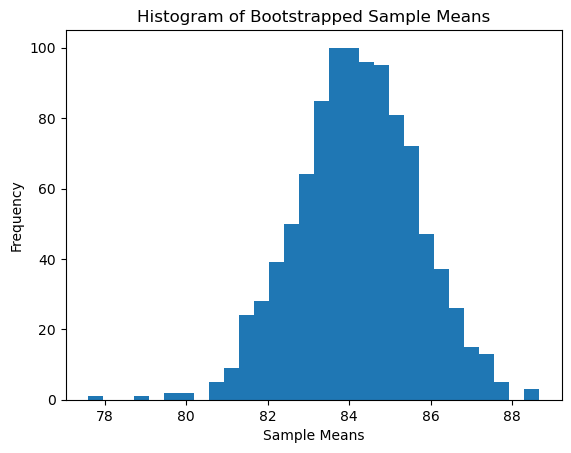

In [9]:
# SECTION 8 — HISTOGRAM (FIXED)

from matplotlib import pyplot as plt

plt.hist(bootstrapped_means, bins=30)

plt.title('Histogram of Bootstrapped Sample Means')
plt.xlabel('Sample Means')
plt.ylabel('Frequency')

plt.show()

## Summary

- The sample mean provides an estimate of the population mean.
- The confidence interval gives a range of likely values for the true mean.
- Bootstrapping confirms the variability and uncertainty of the estimate.
- The histogram shows an approximately normal distribution of sample means.

## Conclusion

This analysis demonstrates how sampling and resampling techniques can be used to estimate population parameters and quantify uncertainty in statistical inference.

## Quiz Questions: Statistical Inference

In [10]:
# Q1: Select a random sample of 40
numpy.random.seed(12)
sample = numpy.random.choice(dBP, 40)
sample

array([ 83.49714463,  79.88573999,  84.32100305,  79.10639494,
        56.97869701,  90.11725308,  84.04071861,  66.1504419 ,
        82.35210789,  73.01673599,  89.41811549,  84.87311253,
        68.36733545,  76.50244101,  99.10891802,  88.68657775,
        89.9843672 , 102.79917781,  91.3090875 ,  80.81765709,
        84.94867166, 103.87940259,  86.76629265,  87.96908022,
        79.37533937,  85.47673774,  85.35313238,  79.06659659,
        78.37321425,  98.45670348,  90.28112062,  95.86742651,
        82.97225589,  84.32323915,  78.39430941,  73.58069404,
        79.81109108,  86.12892486,  83.5339598 ,  92.27264675])

In [11]:
# Q2: Calculate sample mean
sample_mean = sample.mean()
sample_mean

np.float64(84.20409664941648)

In [12]:
# Q3: Calculate sample standard deviation
sample_std = sample.std(ddof=1)
sample_std

np.float64(9.343691253800298)

In [13]:
# Q4: Calculate standard error
standard_error = sample_std / numpy.sqrt(40)
standard_error

np.float64(1.4773673057701677)

In [14]:
# Q5: Confidence coefficient
c = stats.t.ppf(0.975, 39)
c

np.float64(2.0226909200367604)

In [15]:
# Q6: Lower bound of confidence interval
lower_bound = sample_mean - c * standard_error
lower_bound

np.float64(81.21583921447599)

In [16]:
# Q7: Upper bound of confidence interval
upper_bound = sample_mean + c * standard_error
upper_bound

np.float64(87.19235408435698)

In [17]:
# Q8: Bootstrapped sample means
numpy.random.seed(12)

bootstrapped_means = [
    numpy.random.choice(sample, 40, replace=True).mean()
    for _ in range(1000)
]

bootstrapped_means.sort()

In [18]:
# Q9: 2.5th percentile
bootstrapped_means[24]

np.float64(81.37323193289478)

In [19]:
# Q10: 97.5th percentile
bootstrapped_means[974]

np.float64(87.12212722196925)